In [ ]:

from audio_utils import merge_times, get_release_times, read_list_from_file, write_list_to_file, pair_bowler_faces_with_batting
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
    

# Example usage
times = [1, 2.5, 3, 5, 6.5, 7, 10]
merged = merge_times(times)
print(merged)


[1, 2.5, 5, 6.5, 10]


In [ ]:

# Load audio
audio_file = "output_mono.wav"
y, sr = librosa.load(audio_file, sr=None)

release_times = get_release_times(y, percentile=99.50)
final_times = merge_times(release_times)
print("Ball release and stroke times:", release_times)
print("Final times:", final_times)

Ball release and stroke times: [0.1044898  1.62539683 4.26086168]
Final times: [0.10448979591836735, 1.6253968253968254, 4.260861678004535]


In [ ]:

write_list_to_file('batting_peaks.txt', release_times)


In [56]:
def read_list_from_file(filename):
    """
    Read a list from a text file, assuming each element is on a new line.

    :param filename: The name of the file to read from.
    :return: A list of elements read from the file.
    """
    with open(filename, 'r') as file:
        return [float(line.strip()) for line in file.readlines()]

# Example usage
read_data = read_list_from_file('batting_peaks.txt')
print(read_data)


[0.10448979591836735, 1.6253968253968254, 4.260861678004535]


In [ ]:


# Example usage:
batting_peaks = [0,1, 1.2, 3.5, 5.0, 6.8, 9.1]  # Example batting peak times (sorted)
bowler_faces = [2.0, 4.0, 6.5, 8.0, 10.0]  # Example bowler face timestamps (sorted)

# Call the function to get paired times
paired_batting_times = pair_bowler_faces_with_batting(batting_peaks, bowler_faces)
print(paired_batting_times)


{2.0: 1.2, 4.0: 3.5, 6.5: 5.0, 8.0: 6.8, 10.0: 9.1}


In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')  # Use a compatible style
import pandas as pd

# Load Audio File
audio_file = "output_mono.wav"  # Replace with your actual file
y, sr = librosa.load(audio_file, sr=None, duration=2)

44100


In [42]:
import librosa
import numpy as np
import soundfile as sf

def filter_frequencies_in_range(audio_file, freq_range=(100, 1000), output_file="filtered_output.wav"):
    # Load audio file
    y, sr = librosa.load(audio_file, sr=None)
    
    # Compute the STFT (spectrogram)
    D = librosa.stft(y, hop_length=512)
    
    # Get the corresponding frequencies for the spectrogram
    frequencies = librosa.fft_frequencies(sr=sr)
    
    # Create a mask that keeps only the frequencies in the given range
    freq_mask = np.logical_and(frequencies >= freq_range[0], frequencies <= freq_range[1])
    
    # Apply the frequency mask to the STFT (zero out unwanted frequencies)
    D_filtered = D.copy()
    D_filtered[~freq_mask, :] = 0
    
    # Reconstruct the audio from the filtered spectrogram using inverse STFT
    y_filtered = librosa.istft(D_filtered, hop_length=512)
    return y_filtered
    # # Save the filtered audio to a new file
    # sf.write(output_file, y_filtered, sr)

    # print(f"Filtered audio saved to {output_file}")

# Example usage
audio_file = "output_mono.wav"
y = filter_frequencies_in_range(audio_file, freq_range=(100, 512), output_file="filtered_output.wav")
release_times = get_release_times(y, percentile=99.50)
print("Ball release and stroke times:", release_times)

Ball release and stroke times: [0.1044898  0.82430839 1.62539683 4.26086168 4.36535147]


[0.10448979591836735, 1.6253968253968254, 4.260861678004535]


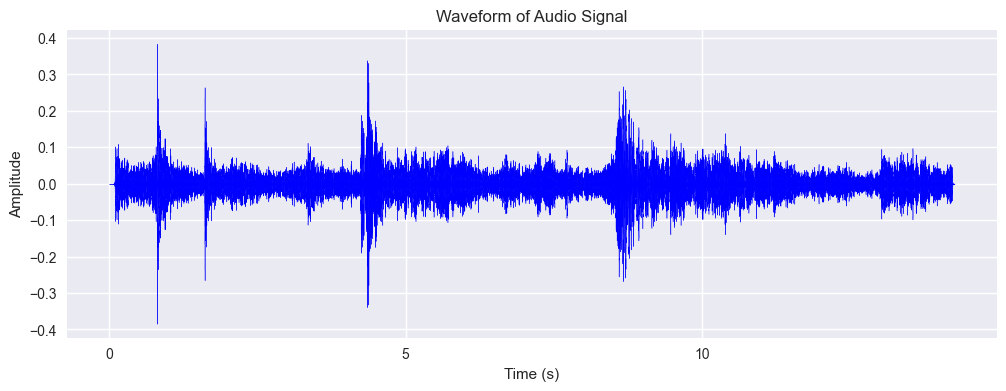

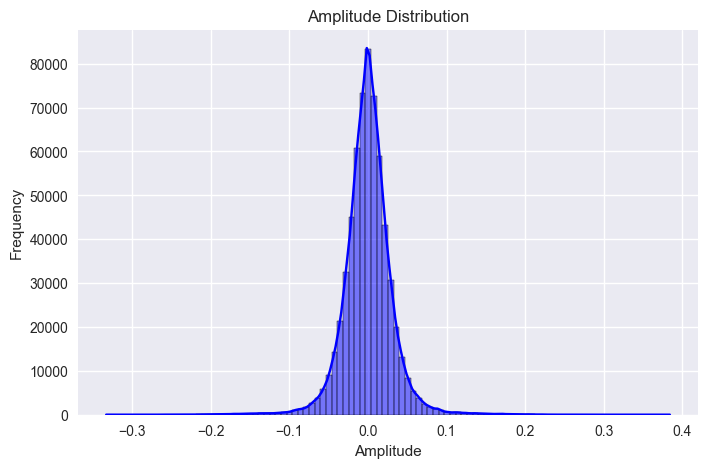

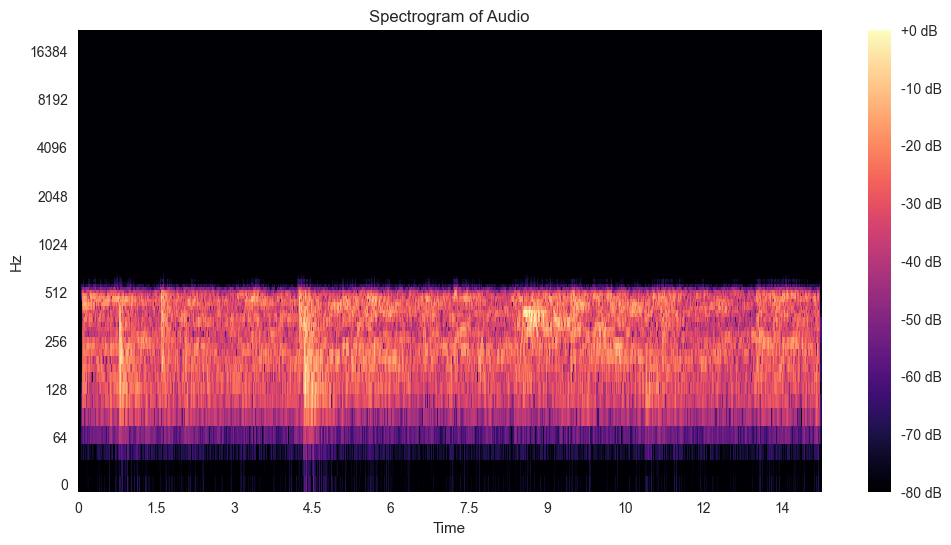

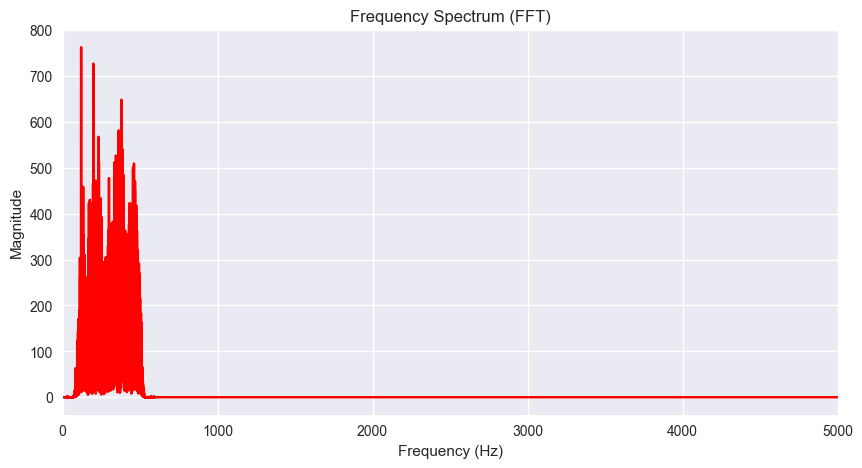

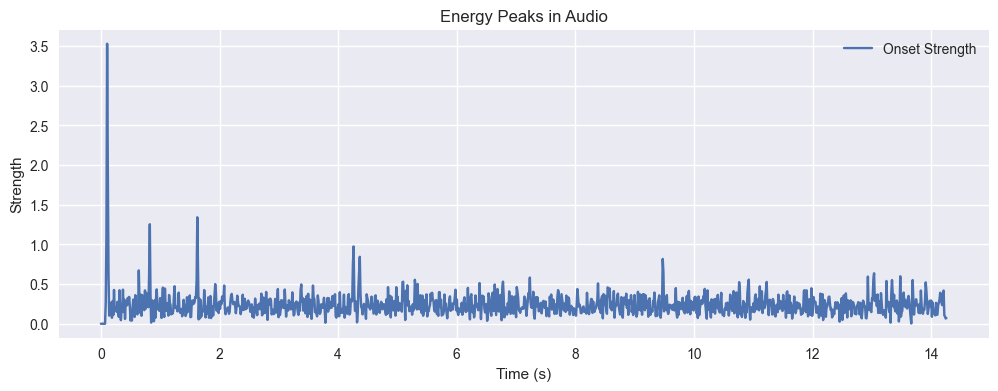

In [31]:

# ---- 1. Plot Waveform ----
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr, color="blue")
plt.title("Waveform of Audio Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# ---- 2. Plot Amplitude Distribution ----
plt.figure(figsize=(8, 5))
sns.histplot(y, bins=100, kde=True, color='blue')
plt.title("Amplitude Distribution")
plt.xlabel("Amplitude")
plt.ylabel("Frequency")
plt.show()

# ---- 3. Spectrogram (Time vs Frequency) ----
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
plt.figure(figsize=(12, 6))
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram of Audio")
plt.show()

# ---- 4. Frequency Spectrum (FFT Analysis) ----
N = len(y)  # Number of samples
T = 1 / sr  # Sampling interval
yf = fft(y)  # Compute FFT
xf = fftfreq(N, T)[:N//2]  # Frequency bins

plt.figure(figsize=(10, 5))
plt.plot(xf, np.abs(yf[:N//2]), color='red')
plt.title("Frequency Spectrum (FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 5000)  # Focus on relevant frequency range (0-5kHz)
plt.show()

# ---- 5. Onset Strength (Detect Energy Spikes) ----
onset_env = librosa.onset.onset_strength(y=y, sr=sr)
plt.figure(figsize=(12, 4))
plt.plot(librosa.times_like(onset_env, sr=sr), onset_env, label="Onset Strength")
plt.title("Energy Peaks in Audio")
plt.xlabel("Time (s)")
plt.ylabel("Strength")
plt.legend()
plt.show()


Time 0.10s - 100-512 Hz: 0.44, 128-2048 Hz: 0.75
Ball Release Times: []
Bat Impact Times: []


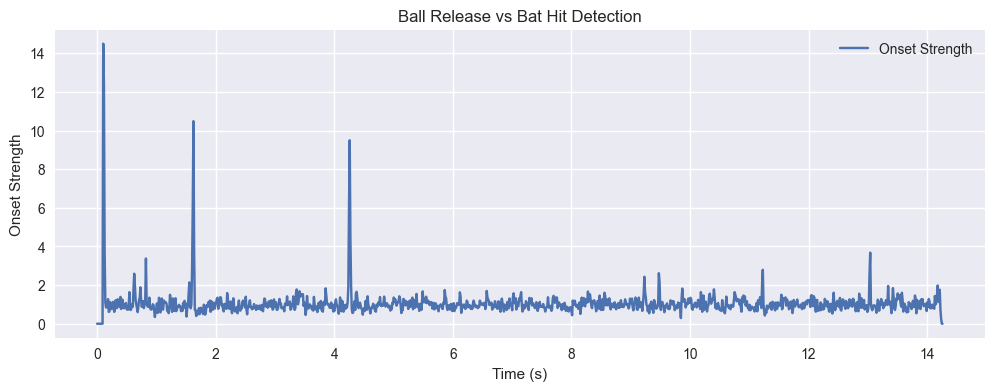

In [29]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Load Audio
audio_file = "output_mono.wav"
y, sr = librosa.load(audio_file, sr=None)

# Compute STFT (Spectrogram)
D = librosa.stft(y, hop_length=512)
D_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
frequencies = librosa.fft_frequencies(sr=sr)
time_frames = librosa.frames_to_time(np.arange(D.shape[1]), sr=sr)

# Compute onset strength
onset_env = librosa.onset.onset_strength(y=y, sr=sr)

# Detect Peaks (Energy Peaks)
peaks, _ = find_peaks(onset_env, height=np.percentile(onset_env, 95), distance=sr//5)
event_times = librosa.frames_to_time(peaks, sr=sr)

# Convert event times to STFT frame indices
stft_peaks = librosa.time_to_frames(event_times, sr=sr, hop_length=512)

# Frequency Band Selection
idx_100_512 = np.where((frequencies >= 100) & (frequencies <= 512))[0]
idx_128_2048 = np.where((frequencies >= 128) & (frequencies <= 2048))[0]

# Classify Peaks Based on Frequency Bands
ball_release_times = []
bat_hit_times = []
last_ball_release_time = None

# Refined detection logic
for peak in stft_peaks:
    if peak >= D.shape[1]:  # Ensure peak index is within valid STFT frame range
        continue

    # Take a small time window around peak (±2 frames)
    frame_range = range(max(0, peak - 2), min(D.shape[1], peak + 3))
    
    # Compute mean energy across window
    frame_energy = np.mean(np.abs(D[:, frame_range]), axis=1)
    total_energy = np.sum(frame_energy)
    
    energy_100_512 = np.sum(frame_energy[idx_100_512]) / total_energy
    energy_128_2048 = np.sum(frame_energy[idx_128_2048]) / total_energy

    # Debugging: Print frequencies at detected peak
    print(f"Time {time_frames[peak]:.2f}s - 100-512 Hz: {energy_100_512:.2f}, 128-2048 Hz: {energy_128_2048:.2f}")

    # Ball release if 100-512 Hz dominates
    if energy_100_512 > 0.50 and energy_100_512 > energy_128_2048:
        ball_release_times.append(time_frames[peak])
        last_ball_release_time = time_frames[peak]  # Store last release time
    
    # Bat hit if 128-2048 Hz dominates **AND happens after ball release**
    elif energy_128_2048 > 0.60 and energy_128_2048 > energy_100_512:
        if last_ball_release_time and time_frames[peak] > last_ball_release_time + 0.2:  # Ensure it's later
            bat_hit_times.append(time_frames[peak])

# Print Detected Events
print("Ball Release Times:", ball_release_times)
print("Bat Impact Times:", bat_hit_times)

# Plot Results
plt.figure(figsize=(12, 4))
plt.plot(librosa.times_like(onset_env, sr=sr), onset_env, label="Onset Strength")

for t in ball_release_times:
    plt.axvline(x=t, color="green", linestyle="--", alpha=0.7, label="Ball Release" if t == ball_release_times[0] else "")

for t in bat_hit_times:
    plt.axvline(x=t, color="red", linestyle="-", alpha=0.7, label="Bat Hit" if t == bat_hit_times[0] else "")

plt.title("Ball Release vs Bat Hit Detection")
plt.xlabel("Time (s)")
plt.ylabel("Onset Strength")
plt.legend()
plt.show()
